# MAPPO Evaluation & Rendering

This runs the trained MAPPO policy with the patrolling zoo.

In [1]:
%reload_ext autoreload
%autoreload 2
from onpolicy.scripts.render.render_pettingzoo import get_config, parse_args, main

import os
import yaml
os.environ["WANDB__SERVICE_WAIT"] = "300"

## Configuration

In [2]:
# Set the run directory.
model_dir = "/data/group/mas/qmas/results/toy_problem_v0/mappo/toy-problem/wandb/run-20250203_171957-rrlgqlw0/files"

In [3]:
# Load arguments from the config file.
config_file = os.path.join(model_dir, "config.yaml")
args = yaml.load(open(config_file), Loader=yaml.FullLoader)

def wrap_arg_val(val):
    return {"value": val}

# Set required render-specific arguments. Do not change these!
args["use_wandb"] = wrap_arg_val(False)
args["use_render"] = wrap_arg_val(True)
args["model_dir"] = wrap_arg_val(model_dir)
args["cuda"] = wrap_arg_val(False)

In [4]:
# Feel free to change these arguments or add additional arguments here.

args["render_episodes"] = wrap_arg_val(1)
args["episode_length"] = wrap_arg_val(3)
args["max_cycles"] = args["episode_length"]

In [5]:
# Convert arguments to the appropriate format.
arglist = []
for key, value in args.items():
    if type(value) == dict and "value" in value and not key.startswith("_"):
        v = value["value"]
        if v == None:
            continue
        if type(v) == bool:
            if v:
                arglist.append(f"--{key}")
            else:
                arglist.append(f"--no-{key}")
        else:
            arglist.append(f"--{key}")
            arglist.append(str(v))

## Perform Rendering

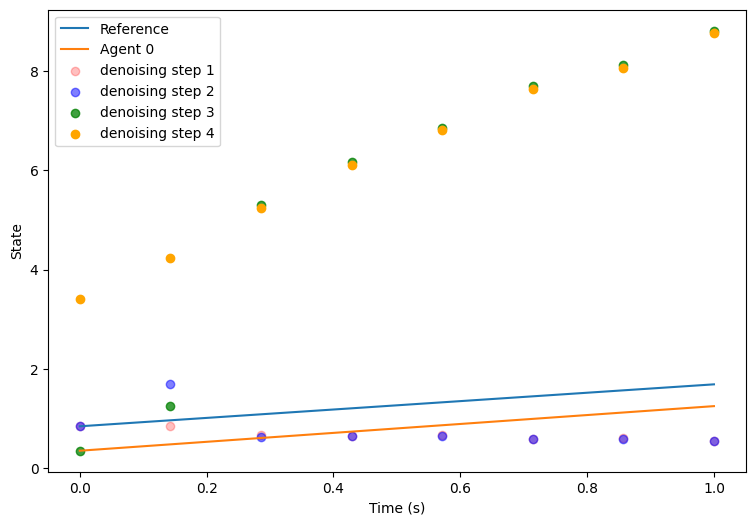

pred:  tensor([[ 4.7423,  1.2502,  1.6888,  0.8444],
        [ 5.8041,  0.0000,  0.0000,  0.7580],
        [ 7.2648,  7.4519,  0.7695,  0.8115],
        [ 8.3649,  8.5655,  0.8337,  0.8548],
        [ 9.3057,  9.4552,  0.8006,  0.8120],
        [10.5661, 10.7704,  0.7602,  0.7762],
        [11.1193, 11.2760,  0.7246,  0.7372],
        [12.2682, 12.4233,  0.6628,  0.6761]])
horizon:  8
denoising step:  4
first:  tensor([0.8444, 0.7580, 0.8115, 0.8548, 0.8120, 0.7762, 0.7372, 0.6761])


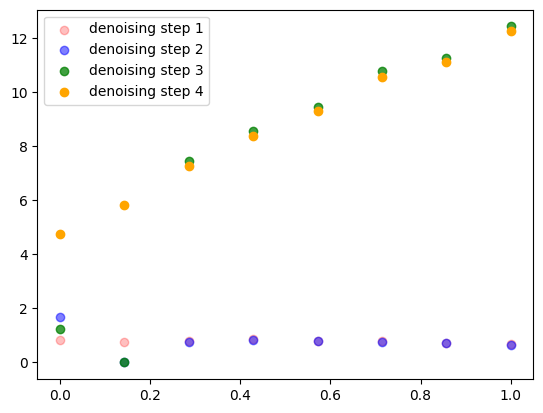

In [6]:
main(arglist)